# Kaggle Titanic- Machine Learning from Disaster

**Goal** Predict which passengers survived the Titanic shipwreck.

## NoteBook Structure

1. Import Libraries
2. Load Data

# Step 1 Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')
#set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries loaded successfully!')

Libraries loaded successfully!


# Step 2 Load Data

In [5]:
# Load, train and test data

# train = pd.read_csv('../data/train.csv')
# test = pd.read_csv('../data/test.csv')

# print(f'Train shape: {train.shape}')
# print(f'Test shape: {test.shape}')

# train.head()


train = pd.read_csv('../data/train.csv')
test =pd.read_csv('../data/test.csv')

print(f'Train Shape : {train.shape}')
print(f'Test Shape: {test.shape}')

train.head()

Train Shape : (891, 12)
Test Shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
#check number of rows,columns,column names, data type of each column, Non-null(non missing) values per column, memory usage.

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [26]:
# Basic statistic for numeric colums

train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
#Check missing values in the train dataframe

print(' ### Missing Values in Train Dataframe ###')
missing_train_data = train.isnull().sum()
print(missing_train_data[missing_train_data > 0])

print('\n === Missing values in Test ===')
missing_test = test.isnull().sum()
print(missing_test[missing_test > 0])

 ### Missing Values in Train Dataframe ###
Age         177
Cabin       687
Embarked      2
dtype: int64

 === Missing values in Test ===
Age       86
Fare       1
Cabin    327
dtype: int64


## Step 3: Exploratory Data Analysis (EDA)

We explore patterns in the data to understand, the feature correlation with WHO was more likely to survive.

### Column Descriptions
| Column | Description |
|--------|-------------|
| `PassengerId` | Unique ID |
| `Survived` | 0 = No, 1 = Yes (TARGET) |
| `Pclass` | Ticket class (1=1st, 2=2nd, 3=3rd) |
| `Name` | Passenger name |
| `Sex` | Gender |
| `Age` | Age in years |
| `SibSp` | # siblings/spouses aboard |
| `Parch` | # parents/children aboard |
| `Ticket` | Ticket number |
| `Fare` | Passenger fare |
| `Cabin` | Cabin number |
| `Embarked` | Port of embarkation (C=Cherbourg, Q=Queenstown, S=Southampton) |

Overal survival rate: 38.38%


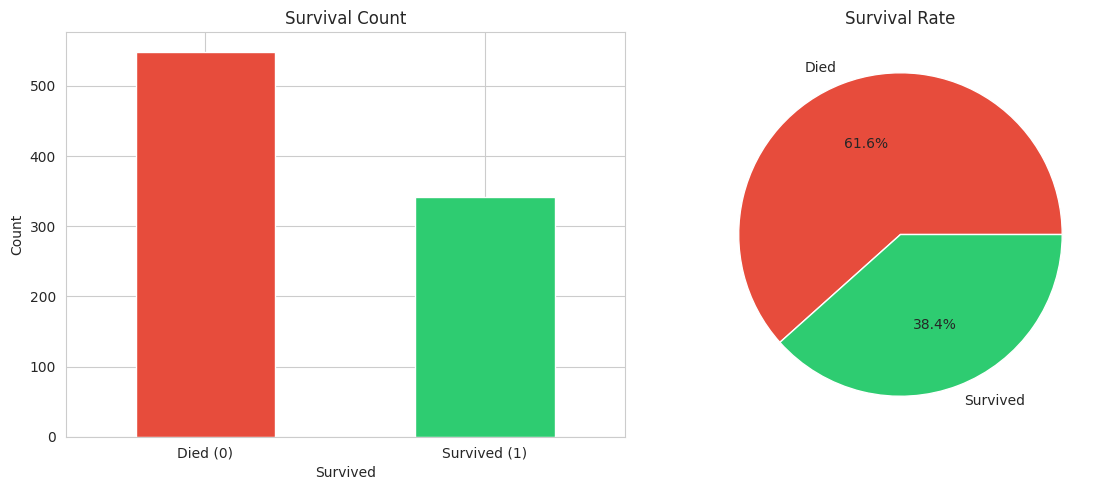

In [18]:
# Overall survival rate
survival_rate = train['Survived'].mean()
print(f'Overal survival rate: {survival_rate:.2%}')

# Plot survival distribution
fig, axes = plt.subplots(1, 2, figsize=(12,5))
train['Survived'].value_counts().plot(kind = 'bar', ax= axes[0],color=['#e74c3c','#2ecc71'])

axes[0].set_title('Survival Count')
axes[0].set_xticklabels(['Died (0)', 'Survived (1)'], rotation=0)
axes[0].set_ylabel('Count')

train['Survived'].value_counts().plot(kind='pie', ax=axes[1], labels=['Died', 'Survived'], 
                                       colors=['#e74c3c','#2ecc71'], autopct='%1.1f%%')
axes[1].set_title('Survival Rate')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()